<a href="https://colab.research.google.com/github/lax-17/pose-guided-diffusion-analysis/blob/main/notebooks/EDA_on_HumanArt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuration and Paths
PROJECT_ROOT = "/content/drive/MyDrive/pose-guided-diffusion-analysis"
UNZIPPED_DATA_ROOT = os.path.join(PROJECT_ROOT, "datasets_unzipped", "HumanArt_v1")
JSON_PATH = os.path.join(UNZIPPED_DATA_ROOT, "HumanArt", "annotations", "training_humanart.json")
OUTPUT_PARQUET = os.path.join(PROJECT_ROOT, "processed_data", "full_humanart_dataset.parquet")

# Plotting Style
sns.set_theme(style="whitegrid", context="talk")
domain_colors = {"natural": "#2ecc71", "2D_virtual": "#3498db", "3D_virtual": "#e74c3c"}

def get_domain(cat):
    """Classifies categories into three macro domains."""
    cat = cat.lower()
    if cat in ['real_human', 'acrobatics', 'cosplay', 'dance', 'drama', 'movie']:
        return 'natural'
    if cat in ['garage_kits', 'relief', 'sculpture', '3D_virtual_human']:
        return '3D_virtual'
    return '2D_virtual'

def fix_path(fname):
    """Corrects file path inconsistencies in the JSON metadata."""
    if fname.startswith("HumanArt/images/"):
        return fname
    elif fname.startswith("images/"):
        return os.path.join("HumanArt", fname)
    else:
        return os.path.join("HumanArt", "images", fname)

In [2]:
if not os.path.exists(JSON_PATH):
    print(f"Error: Could not find JSON at {JSON_PATH}")
else:
    print(f"Parsing raw JSON: {JSON_PATH}")
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)

    # Extract images and annotations
    images_df = pd.DataFrame(data['images']).rename(columns={'id': 'image_id'})
    anns_df = pd.DataFrame(data['annotations']).rename(columns={'id': 'ann_id'})

    # Merge DataFrames
    full_df = pd.merge(anns_df, images_df, on='image_id', how='inner')

    # Apply path correction and filter captions
    full_df['relative_path'] = full_df['file_name'].apply(fix_path)
    full_df = full_df[full_df['description'].notna()]
    full_df = full_df[full_df['description'] != ""]

    # Save to Parquet
    os.makedirs(os.path.dirname(OUTPUT_PARQUET), exist_ok=True)
    full_df.to_parquet(OUTPUT_PARQUET, index=False)

    print("Success: Created Full Dataset")
    print(f"Total Samples: {len(full_df)}")
    print(f"Unique Images: {full_df['image_id'].nunique()}")

Parsing raw JSON: /content/drive/MyDrive/pose-guided-diffusion-analysis/datasets_unzipped/HumanArt_v1/HumanArt/annotations/training_humanart.json
Success: Created Full Dataset
Total Samples: 82630
Unique Images: 33250


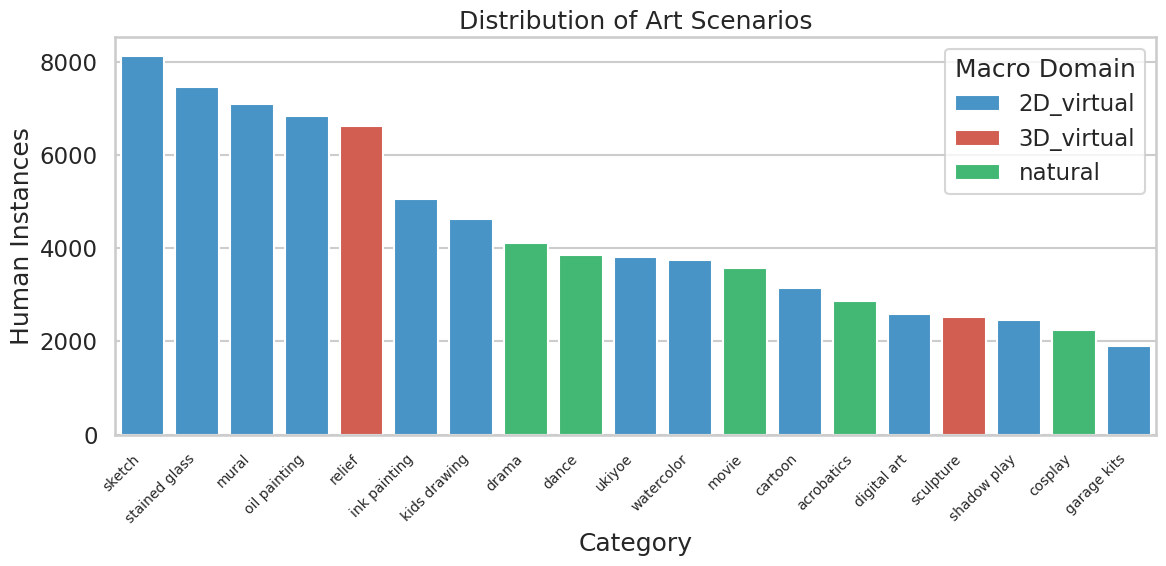

In [3]:
df = pd.read_parquet(OUTPUT_PARQUET)
df['domain_group'] = df['category'].apply(get_domain)

plt.figure(figsize=(12, 6))
order = df['category'].value_counts().index
sns.countplot(data=df, x='category', order=order, hue='domain_group', dodge=False, palette=domain_colors)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Distribution of Art Scenarios")
plt.xlabel("Category")
plt.ylabel("Human Instances")
plt.legend(title="Macro Domain")
plt.tight_layout()
plt.show()

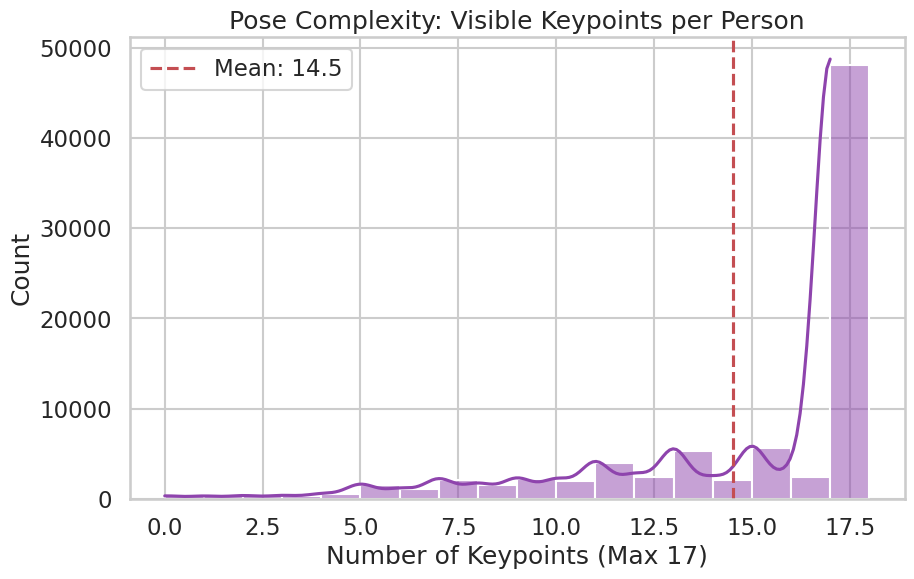

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='num_keypoints', bins=range(0, 19), kde=True, color="#8e44ad")
plt.title("Pose Complexity: Visible Keypoints per Person")
plt.xlabel("Number of Keypoints (Max 17)")
plt.axvline(df['num_keypoints'].mean(), color='r', linestyle='--', label=f"Mean: {df['num_keypoints'].mean():.1f}")
plt.legend()
plt.show()

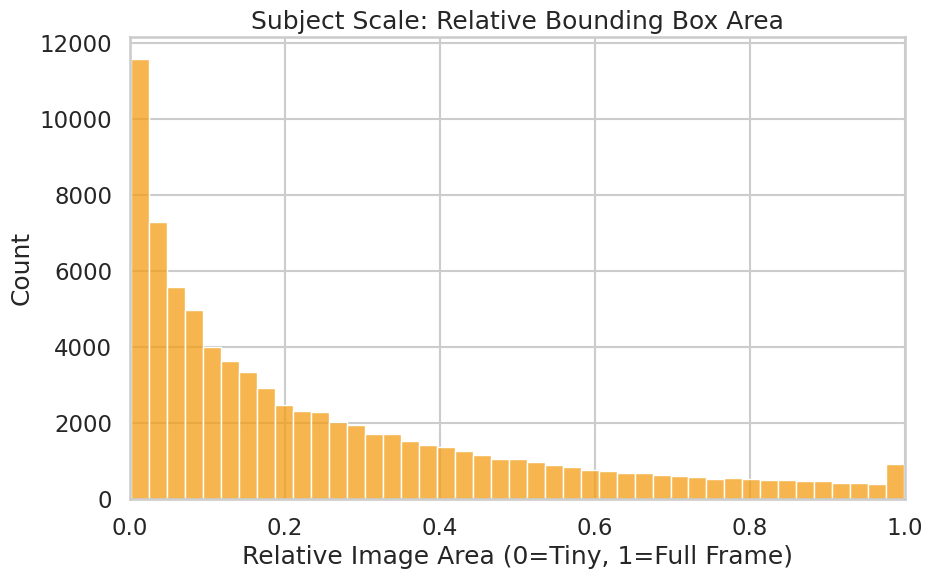

In [5]:
df['relative_area'] = df['area'] / (df['width'] * df['height'])

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='relative_area', bins=50, color="#f39c12")
plt.title("Subject Scale: Relative Bounding Box Area")
plt.xlabel("Relative Image Area (0=Tiny, 1=Full Frame)")
plt.xlim(0, 1)
plt.show()

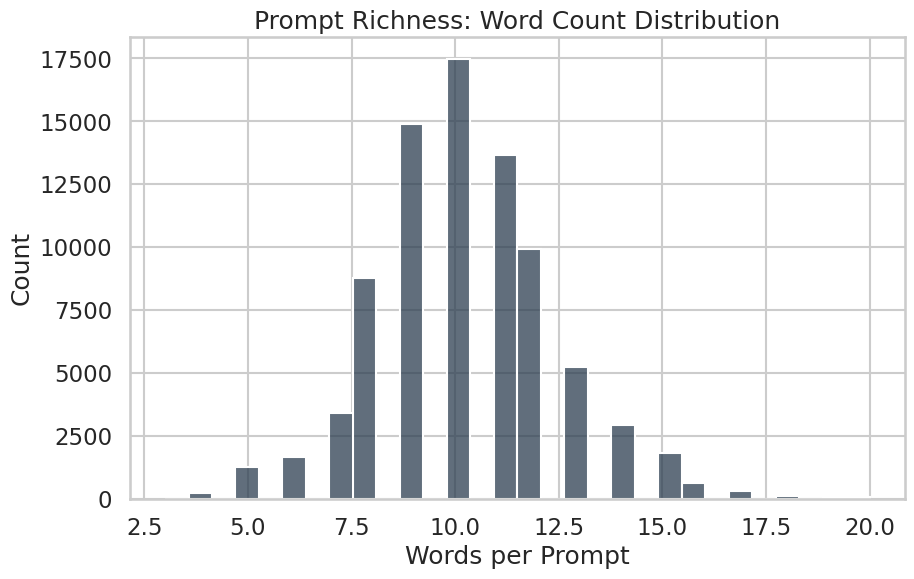

/tmp/ipython-input-2161750112.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[x[1] for x in common_words], y=[x[0] for x in common_words], palette="viridis")


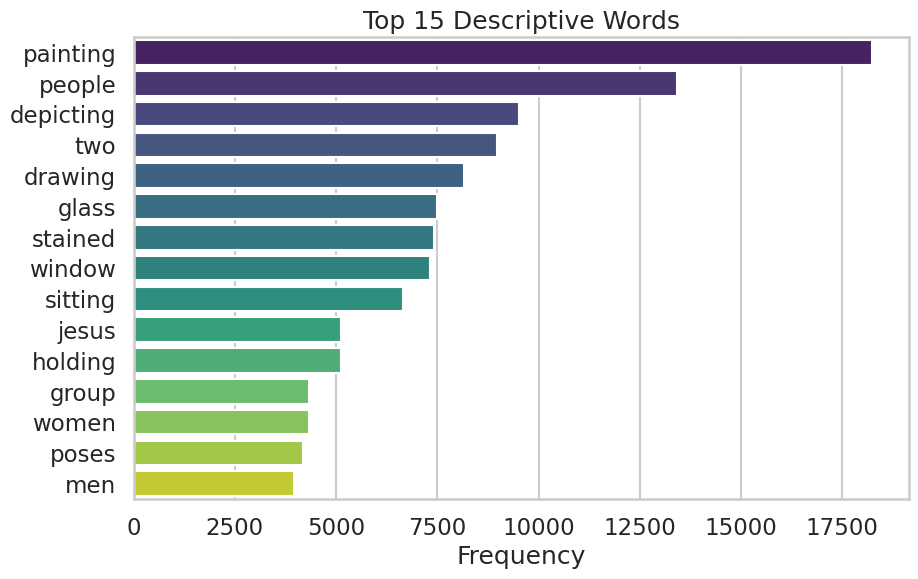

In [6]:
# Plot A: Prompt Length
df['word_count'] = df['description'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', bins=30, color="#2c3e50")
plt.title("Prompt Richness: Word Count Distribution")
plt.xlabel("Words per Prompt")
plt.show()

# Plot B: Top Descriptive Words
all_text = " ".join(df['description'].astype(str).tolist()).lower()
stops = set(['a', 'an', 'the', 'in', 'on', 'of', 'with', 'is', 'and', 'at', 'to', 'woman', 'man', 'person'])
words = [w for w in all_text.split() if w not in stops and w.isalpha()]
common_words = Counter(words).most_common(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=[x[1] for x in common_words], y=[x[0] for x in common_words], palette="viridis")
plt.title("Top 15 Descriptive Words")
plt.xlabel("Frequency")
plt.show()

Calculating TF-IDF to find unique style triggers...


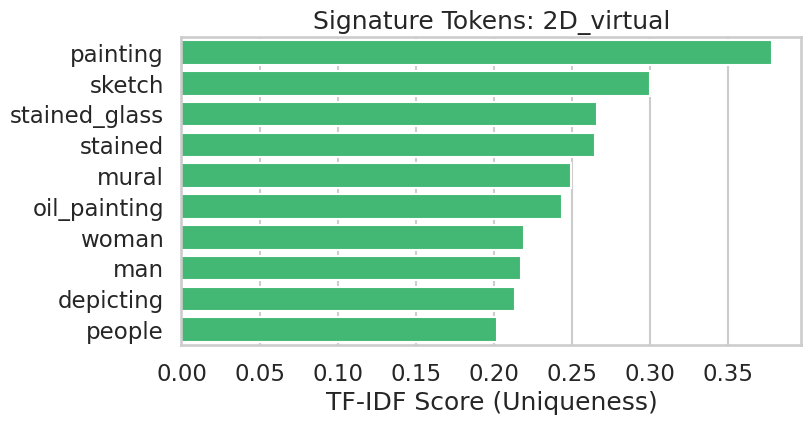

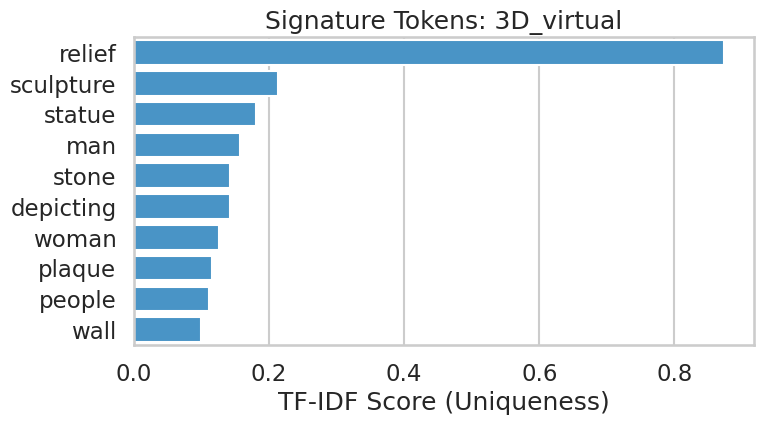

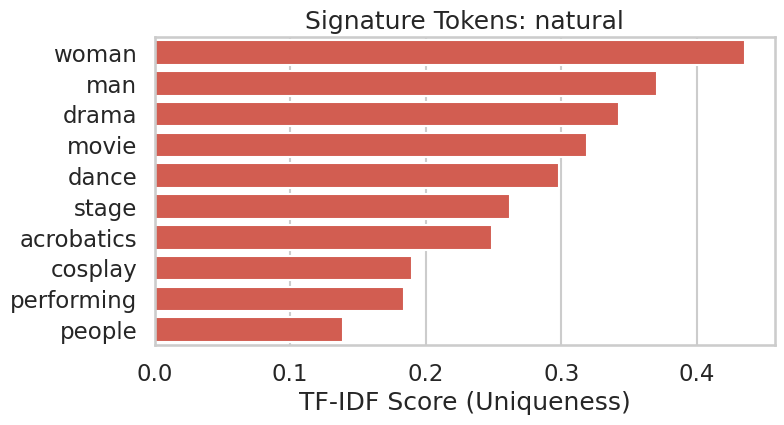

In [7]:
print("Calculating TF-IDF to find unique style triggers...")

# Prepare grouped text
grouped_text = df.groupby('domain_group')['description'].apply(lambda x: " ".join(x.astype(str))).reset_index()
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(grouped_text['description'])
feature_names = np.array(tfidf.get_feature_names_out())

# Plot signatures for each domain
colors = ['#2ecc71', '#3498db', '#e74c3c']
for i, domain in enumerate(grouped_text['domain_group']):
    plt.figure(figsize=(8, 4))
    row_data = tfidf_matrix[i].toarray().flatten()
    top_indices = row_data.argsort()[-10:][::-1]
    top_words = feature_names[top_indices]
    top_scores = row_data[top_indices]

    sns.barplot(x=top_scores, y=top_words, color=colors[i])
    plt.title(f"Signature Tokens: {domain}")
    plt.xlabel("TF-IDF Score (Uniqueness)")
    plt.show()

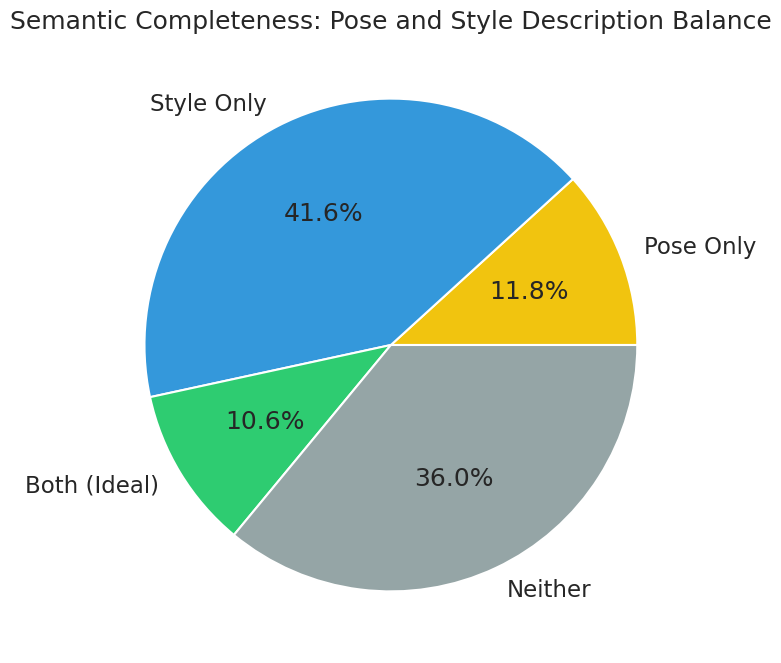

In [8]:
pose_verbs = ['standing', 'sitting', 'running', 'walking', 'holding', 'jumping', 'dancing']
art_nouns = ['drawing', 'painting', 'sculpture', 'statue', 'cartoon', 'sketch', 'photo']

def check_content(text):
    text = str(text).lower()
    has_pose = any(v in text for v in pose_verbs)
    has_style = any(n in text for n in art_nouns)
    return has_pose, has_style

results = df['description'].apply(check_content)
df['has_pose_desc'] = [x[0] for x in results]
df['has_style_desc'] = [x[1] for x in results]

counts = {
    "Pose Only": len(df[df['has_pose_desc'] & ~df['has_style_desc']]),
    "Style Only": len(df[~df['has_pose_desc'] & df['has_style_desc']]),
    "Both (Ideal)": len(df[df['has_pose_desc'] & df['has_style_desc']]),
    "Neither": len(df[~df['has_pose_desc'] & ~df['has_style_desc']])
}

plt.figure(figsize=(8, 8))
plt.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%', colors=['#f1c40f', '#3498db', '#2ecc71', '#95a5a6'])
plt.title("Semantic Completeness: Pose and Style Description Balance")
plt.show()

In [9]:
print("Key Metrics for Methodology Section")
print("-" * 30)
print(f"Total Human Instances: {len(df)}")
print(f"Mean Keypoints per Person: {df['num_keypoints'].mean():.2f}")
print(f"Mean Prompt Length: {df['word_count'].mean():.2f} words")
print(f"Small Objects (Under 5% area): {(df['relative_area'] < 0.05).mean()*100:.1f}%")
print(f"Prompts with Pose Actions: {df['has_pose_desc'].mean()*100:.1f}%")

Key Metrics for Methodology Section
------------------------------
Total Human Instances: 82630
Mean Keypoints per Person: 14.53
Mean Prompt Length: 10.26 words
Small Objects (Under 5% area): 26.8%
Prompts with Pose Actions: 22.4%
